# Testing models

In [ ]:
import torch
import torch.nn as nn
from models.blocks import ConvNeXtcausal
from torch.nn.utils.parametrizations import weight_norm
#from transformers import EncodecModel
from utils.mel import MelSpectra

No module named 'flash_attn'
flash_attn not installed, disabling Flash Attention
No module named 'flash_attn'
flash_attn varlen/bert_padding not available, disabling varlen attention


In [38]:
mel_extractor = MelSpectra(
    sample_rate=24000,
    n_fft=1024,
    hop_length=256,
    n_mels=128
)

In [2]:
import torch
from models.slow_branch import Conv_SlowBranch

audio = torch.randn(1, 1, 48000)
encoder = Conv_SlowBranch(1, 128, 128, 256, 2)
emb = encoder(audio)
print(emb.shape)

torch.Size([1, 128, 94])


In [25]:
x = torch.ones(1, 1, 24000)
model = EncodecModel.from_pretrained('facebook/encodec_24khz')
with torch.no_grad():
    emb = model.encoder(x)
    #emb = (emb - emb.mean(dim=-1, keepdim=True)) / (emb.std(dim=-1, keepdim=True) + 1e-5)
print(f"Encoder output shape: {emb.shape}")
print(f"Encoder output mean: {emb.mean().item():.4f}, std: {emb.std().item():.4f}")

Loading weights: 100%|██████████| 252/252 [00:00<00:00, 3322.05it/s]


Encoder output shape: torch.Size([1, 128, 75])
Encoder output mean: -1.1315, std: 8.3578


In [33]:
import sys
import torch
import torchaudio
sys.path.append('../stable-audio-3')
from stable_audio_3 import AutoencoderModel

x, sr = torchaudio.load('/home/lois/wavenext/logs/05-06_at_03_27_42/wavenext/version_0/audio_epoch_80/sample_0_real.wav')
x = torchaudio.functional.resample(x, orig_freq=sr, new_freq=44100)
ae = AutoencoderModel.from_pretrained("same-s")
with torch.no_grad():
    emb = ae.encode(x, 44100)
print(f"Autoencoder output shape: {emb.shape}")

audio_out = ae.decode(emb)

from IPython.display import Audio
Audio(audio_out.cpu().squeeze(), rate=44100)

Autoencoder output shape: torch.Size([1, 256, 12])


In [38]:
x = torch.randn(1, 1, 4096)
with torch.no_grad():
    emb = ae.encode(x, 44100)
print(f"Autoencoder output shape: {emb.shape}")

Autoencoder output shape: torch.Size([1, 256, 2])


In [3]:
class Decoder(nn.Module):
    def __init__(self, in_channels: int, dim: int, shift_dim: int, inter_channels: int, num_blocks: int):
        super(Decoder, self).__init__()
        self.pad_input = nn.ConstantPad1d((6, 0), 0)
        self.conv = nn.Conv1d(in_channels, dim, kernel_size=7, padding=0)
        self.norm = nn.LayerNorm(dim, eps=1e-6)
        self.blocks = nn.ModuleList([ConvNeXtcausal(dim, inter_channels) for _ in range(num_blocks)])
        self.linear1 = nn.Linear(dim, dim)
        self.linear2 = nn.Linear(dim, shift_dim, bias=False) 
        # (B, shift_dim, T) -> (B, 1 , shift_dim * T)
    
    def forward(self, x):
        x = self.pad_input(x)
        x = self.conv(x)
        x = x.transpose(1, 2)  # (B, T, dim)
        x = self.norm(x)
        x = x.transpose(1, 2)  # (B, dim, T)

        for block in self.blocks:
            x = block(x)

        x = x.transpose(1, 2)  # (B, T, dim)
        x = self.linear1(x)
        x = self.linear2(x) # (B, T, shift_dim)
        x = x.view(x.size(0), -1) # (B, shift_dim * T)

        return x

In [21]:
s_dim = x.size(-1) // emb.size(-1)
decoder = Decoder(in_channels=128, dim=512, shift_dim=s_dim, inter_channels=256, num_blocks=2)
decoder = decoder.to(emb.device) 
y = decoder(emb)
print(f"Decoder output shape: {y.shape}")

Decoder output shape: torch.Size([1, 24000])


In [26]:
with torch.no_grad():
    y = model.decoder(emb)

In [27]:
import torch.nn.functional as F
mel_original = mel_extractor(x)
mel_reconstructed = mel_extractor(y)
print(f"EnCodec native mel loss: {F.l1_loss(mel_reconstructed, mel_original).item():.4f}")

EnCodec native mel loss: 53.4766


In [5]:
import torch
import yaml
from models.wavenext_prior import WaveNeXtLatent
import torchaudio

def load_config(config_path):
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    return config

config = load_config('/home/lois/wavenext/config_prior_24k.yaml')

model = WaveNeXtLatent(
        dim=config['dim'],
        sample_rate=config['sample_rate'],
        fft_dim=config['fft_dim'],
        shift_dim=config['shift_dim'],
        n_mels=config['n_mels'],
        k=config['k'],
        lr_g=config['learning_rate_g'],
        lr_d=config['learning_rate_d'],
        prior=config['prior']
    ).to('cuda')

model.load_state_dict(torch.load("/home/lois/wavenext/checkpoints/05-06_at_03_27_42/wavenext-epoch=88-val_mel_loss=0.893.ckpt")['state_dict'])
model.eval()

/home/lois/miniconda3/envs/latency/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


WaveNeXtLatent(
  (decoder): Decoder(
    (pad_input): ConstantPad1d(padding=(6, 0), value=0)
    (conv): Conv1d(128, 512, kernel_size=(7,), stride=(1,))
    (norm): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
    (blocks): ModuleList(
      (0-7): 8 x ConvNeXtcausal(
        (pad): ConstantPad1d(padding=(6, 0), value=0)
        (depthwise): Conv1d(512, 512, kernel_size=(7,), stride=(1,), groups=512)
        (norm): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (pointwise1): Linear(in_features=512, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (pointwise2): Linear(in_features=1536, out_features=512, bias=True)
      )
    )
    (linear1): Linear(in_features=512, out_features=512, bias=True)
    (linear2): Linear(in_features=512, out_features=320, bias=False)
  )
  (discriminator_mpd): MPD(
    (discriminators): ModuleList(
      (0-4): 5 x OnePeriod(
        (conv): ModuleList(
          (0): ParametrizedConv2d(
            1, 3

In [12]:
from encodec import EncodecModel
import torch
wav = torch.randn(1, 1, 24000)

model = EncodecModel.encodec_model_24khz()
model.set_target_bandwidth(12.0)

with torch.no_grad():
    encoded_frames = model.encode(wav) 
    codes = torch.cat([f[0] for f in encoded_frames], dim=-1)  # [B, n_q, T]
    emb = model.quantizer.decode(codes.transpose(0, 1))

print(f"Encoder output shape: {emb.shape}")


Encoder output shape: torch.Size([1, 128, 75])


In [10]:
import torch
import typing as tp
import torch.nn as nn
import numpy as np
import warnings
import math
from torch.nn.utils import spectral_norm, weight_norm
import einops
import torch.nn.functional as F

CONV_NORMALIZATIONS = frozenset(['none', 'weight_norm', 'spectral_norm',
                                 'time_layer_norm', 'layer_norm', 'time_group_norm'])

class ConvLayerNorm(nn.LayerNorm):
    """
    Convolution-friendly LayerNorm that moves channels to last dimensions
    before running the normalization and moves them back to original position right after.
    """
    def __init__(self, normalized_shape: tp.Union[int, tp.List[int], torch.Size], **kwargs):
        super().__init__(normalized_shape, **kwargs)

    def forward(self, x):
        x = einops.rearrange(x, 'b ... t -> b t ...')
        x = super().forward(x)
        x = einops.rearrange(x, 'b t ... -> b ... t')
        return

def apply_parametrization_norm(module: nn.Module, norm: str = 'none') -> nn.Module:
    assert norm in CONV_NORMALIZATIONS
    if norm == 'weight_norm':
        return weight_norm(module)
    elif norm == 'spectral_norm':
        return spectral_norm(module)
    else:
        # We already check was in CONV_NORMALIZATION, so any other choice
        # doesn't need reparametrization.
        return module

def get_norm_module(module: nn.Module, causal: bool = False, norm: str = 'none', **norm_kwargs) -> nn.Module:
    """Return the proper normalization module. If causal is True, this will ensure the returned
    module is causal, or return an error if the normalization doesn't support causal evaluation.
    """
    assert norm in CONV_NORMALIZATIONS
    if norm == 'layer_norm':
        assert isinstance(module, nn.modules.conv._ConvNd)
        return ConvLayerNorm(module.out_channels, **norm_kwargs)
    elif norm == 'time_group_norm':
        if causal:
            raise ValueError("GroupNorm doesn't support causal evaluation.")
        assert isinstance(module, nn.modules.conv._ConvNd)
        return nn.GroupNorm(1, module.out_channels, **norm_kwargs)
    else:
        return nn.Identity()


def pad1d(x: torch.Tensor, paddings: tp.Tuple[int, int], mode: str = 'zero', value: float = 0.):
    """Tiny wrapper around F.pad, just to allow for reflect padding on small input.
    If this is the case, we insert extra 0 padding to the right before the reflection happen.
    """
    length = x.shape[-1]
    padding_left, padding_right = paddings
    assert padding_left >= 0 and padding_right >= 0, (padding_left, padding_right)
    if mode == 'reflect':
        max_pad = max(padding_left, padding_right)
        extra_pad = 0
        if length <= max_pad:
            extra_pad = max_pad - length + 1
            x = F.pad(x, (0, extra_pad))
        padded = F.pad(x, paddings, mode, value)
        end = padded.shape[-1] - extra_pad
        return padded[..., :end]
    else:
        return F.pad(x, paddings, mode, value)

def get_extra_padding_for_conv1d(x: torch.Tensor, kernel_size: int, stride: int,
                                 padding_total: int = 0) -> int:
    """See `pad_for_conv1d`.
    """
    length = x.shape[-1]
    n_frames = (length - kernel_size + padding_total) / stride + 1
    ideal_length = (math.ceil(n_frames) - 1) * stride + (kernel_size - padding_total)
    return ideal_length - length


class NormConv1d(nn.Module):
    """Wrapper around Conv1d and normalization applied to this conv
    to provide a uniform interface across normalization approaches.
    """
    def __init__(self, *args, causal: bool = False, norm: str = 'none',
                 norm_kwargs: tp.Dict[str, tp.Any] = {}, **kwargs):
        super().__init__()
        self.conv = apply_parametrization_norm(nn.Conv1d(*args, **kwargs), norm)
        self.norm = get_norm_module(self.conv, causal, norm, **norm_kwargs)
        self.norm_type = norm

    def forward(self, x):
        x = self.conv(x)
        x = self.norm(x)
        return x

class SLSTM(nn.Module):
    """
    LSTM without worrying about the hidden state, nor the layout of the data.
    Expects input as convolutional layout.
    """
    def __init__(self, dimension: int, num_layers: int = 2, skip: bool = True):
        super().__init__()
        self.skip = skip
        self.lstm = nn.LSTM(dimension, dimension, num_layers)

    def forward(self, x):
        x = x.permute(2, 0, 1)
        y, _ = self.lstm(x)
        if self.skip:
            y = y + x
        y = y.permute(1, 2, 0)
        return y

class SConv1d(nn.Module):
    """Conv1d with some builtin handling of asymmetric or causal padding
    and normalization.
    """
    def __init__(self, in_channels: int, out_channels: int,
                 kernel_size: int, stride: int = 1, dilation: int = 1,
                 groups: int = 1, bias: bool = True, causal: bool = False,
                 norm: str = 'none', norm_kwargs: tp.Dict[str, tp.Any] = {},
                 pad_mode: str = 'reflect'):
        super().__init__()
        # warn user on unusual setup between dilation and stride
        if stride > 1 and dilation > 1:
            warnings.warn('SConv1d has been initialized with stride > 1 and dilation > 1'
                          f' (kernel_size={kernel_size} stride={stride}, dilation={dilation}).')
        self.conv = NormConv1d(in_channels, out_channels, kernel_size, stride,
                               dilation=dilation, groups=groups, bias=bias, causal=causal,
                               norm=norm, norm_kwargs=norm_kwargs)
        self.causal = causal
        self.pad_mode = pad_mode

    def forward(self, x):
        B, C, T = x.shape
        kernel_size = self.conv.conv.kernel_size[0]
        stride = self.conv.conv.stride[0]
        dilation = self.conv.conv.dilation[0]
        kernel_size = (kernel_size - 1) * dilation + 1  # effective kernel size with dilations
        padding_total = kernel_size - stride
        extra_padding = get_extra_padding_for_conv1d(x, kernel_size, stride, padding_total)
        if self.causal:
            # Left padding for causal
            x = pad1d(x, (padding_total, extra_padding), mode=self.pad_mode)
        else:
            # Asymmetric padding required for odd strides
            padding_right = padding_total // 2
            padding_left = padding_total - padding_right
            x = pad1d(x, (padding_left, padding_right + extra_padding), mode=self.pad_mode)
        return self.conv(x)


class SEANetResnetBlock(nn.Module):

    def __init__(self, dim: int, kernel_sizes: tp.List[int] = [3, 1], dilations: tp.List[int] = [1, 1],
                 activation: str = 'ELU', activation_params: dict = {'alpha': 1.0},
                 norm: str = 'weight_norm', norm_params: tp.Dict[str, tp.Any] = {}, causal: bool = False,
                 pad_mode: str = 'reflect', compress: int = 2, true_skip: bool = True):
        super().__init__()
        assert len(kernel_sizes) == len(dilations), 'Number of kernel sizes should match number of dilations'
        act = getattr(nn, activation)
        hidden = dim // compress
        block = []
        for i, (kernel_size, dilation) in enumerate(zip(kernel_sizes, dilations)):
            in_chs = dim if i == 0 else hidden
            out_chs = dim if i == len(kernel_sizes) - 1 else hidden
            block += [
                act(**activation_params),
                SConv1d(in_chs, out_chs, kernel_size=kernel_size, dilation=dilation,
                        norm=norm, norm_kwargs=norm_params,
                        causal=causal, pad_mode=pad_mode),
            ]
        self.block = nn.Sequential(*block)
        self.shortcut: nn.Module
        if true_skip:
            self.shortcut = nn.Identity()
        else:
            self.shortcut = SConv1d(dim, dim, kernel_size=1, norm=norm, norm_kwargs=norm_params,
                                    causal=causal, pad_mode=pad_mode)

    def forward(self, x):
        return self.shortcut(x) + self.block(x)
    
class SEANetEncoder(nn.Module):
    def __init__(self, channels: int = 1, dimension: int = 128, n_filters: int = 32, n_residual_layers: int = 1,
                 ratios: tp.List[int] = [8, 5, 4, 2], activation: str = 'ELU', activation_params: dict = {'alpha': 1.0},
                 norm: str = 'weight_norm', norm_params: tp.Dict[str, tp.Any] = {}, kernel_size: int = 7,
                 last_kernel_size: int = 7, residual_kernel_size: int = 3, dilation_base: int = 2, causal: bool = False,
                 pad_mode: str = 'reflect', true_skip: bool = False, compress: int = 2, lstm: int = 2):
        super().__init__()
        self.channels = channels
        self.dimension = dimension
        self.n_filters = n_filters
        self.ratios = list(reversed(ratios))
        del ratios
        self.n_residual_layers = n_residual_layers
        self.hop_length = np.prod(self.ratios)

        act = getattr(nn, activation)
        mult = 1
        model: tp.List[nn.Module] = [
            SConv1d(channels, mult * n_filters, kernel_size, norm=norm, norm_kwargs=norm_params,
                    causal=causal, pad_mode=pad_mode)
        ]
        # Downsample to raw audio scale
        for i, ratio in enumerate(self.ratios):
            # Add residual layers
            for j in range(n_residual_layers):
                model += [
                    SEANetResnetBlock(mult * n_filters, kernel_sizes=[residual_kernel_size, 1],
                                      dilations=[dilation_base ** j, 1],
                                      norm=norm, norm_params=norm_params,
                                      activation=activation, activation_params=activation_params,
                                      causal=causal, pad_mode=pad_mode, compress=compress, true_skip=true_skip)]

            # Add downsampling layers
            model += [
                act(**activation_params),
                SConv1d(mult * n_filters, mult * n_filters * 2,
                        kernel_size=ratio * 2, stride=ratio,
                        norm=norm, norm_kwargs=norm_params,
                        causal=causal, pad_mode=pad_mode),
            ]
            mult *= 2

        if lstm:
            model += [SLSTM(mult * n_filters, num_layers=lstm)]

        model += [
            act(**activation_params),
            SConv1d(mult * n_filters, dimension, last_kernel_size, norm=norm, norm_kwargs=norm_params,
                    causal=causal, pad_mode=pad_mode)
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

In [15]:
model = SEANetEncoder(channels=1, dimension=128, n_filters=32, n_residual_layers=1,
                 ratios=[8, 5, 4, 2], activation='ELU', activation_params={'alpha': 1.0},
                 norm='weight_norm', norm_params={}, kernel_size=7, last_kernel_size=7, residual_kernel_size=3, dilation_base=2, causal=True,
                 pad_mode='reflect', true_skip=False, compress=2, lstm=2)
x = torch.randn(1, 1, 48000)
emb = model(x)
print(emb.shape)

torch.Size([1, 128, 150])


In [ ]:
import torch
from models.slow_branch import Transformer_SlowBranch, GRU_SlowBranch, Conv_SlowBranch
from models.decoder import CrossA_Decoder, Cond_Decoder

slow_branch = Transformer_SlowBranch(latent_dim=128, dim=512)
decoder = CrossA_Decoder(in_channels=128, dim=512, shift_dim=320, inter_channels=256, num_blocks=2)

latent = torch.randn(2, 128, 225)
n = latent.size(2)

slow_latent = latent[:, :, :int(n*2/3)]
fast_latent = latent[:, :, slow_latent.size(2):]
print(slow_latent.shape, fast_latent.shape)

K, V = slow_branch(slow_latent.transpose(1,2))
#print(K.shape, V.shape)
#out = decoder(fast_latent, (K, V))

#print(out.shape)

slow_branch = Naive_SlowBranch(latent_dim=128, film_dim=512)
decoder = Cond_Decoder(in_channels=128, dim=512, shift_dim=320, inter_channels=256, num_blocks=2)

a, b = slow_branch(slow_latent.transpose(1,2))
print(a.shape, b.shape)
out = decoder(fast_latent, (a, b))

print(out.shape)
x = torch.randn(1, 1, 72000)
x_fast = x[:, :, int(x.size(2)*(2/3)):]
print(x_fast.shape)

audio = torch.randn(1, 1, 48000)
encoder = Conv_SlowBranch(1, 128, 128, 256, 2)
emb = encoder(audio)
print(emb.shape)

/home/lois/miniconda3/envs/latency/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


torch.Size([2, 128, 150]) torch.Size([2, 128, 75])
torch.Size([2, 512]) torch.Size([2, 512])
torch.Size([2, 24000])
torch.Size([1, 1, 24000])


In [ ]:
import time
import math
import torch
import numpy as np

from models.slow_branch import Transformer_SlowBranch, GRU_SlowBranch
from utils.mel import MelSpectra

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def sync():
    if DEVICE == "cuda":
        torch.cuda.synchronize()

@torch.no_grad()
def bench(name, module, x, chunk_duration_ms, n_warmup=50, n_runs=200):
    module = module.to(DEVICE).eval()
    x = x.to(DEVICE)

    for _ in range(n_warmup):
        module(x)

    sync()

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        module(x)
        sync()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)

    times = np.array(times)
    p95 = np.percentile(times, 95)
    delta_min = math.ceil(p95 / chunk_duration_ms)

    print(f"\n{name}")
    print(f"mean: {times.mean():.3f} ms")
    print(f"p50 : {np.percentile(times, 50):.3f} ms")
    print(f"p95 : {p95:.3f} ms")
    print(f"p99 : {np.percentile(times, 99):.3f} ms")
    print(f"min reuse delta from p95: {delta_min} fast chunks")

if __name__ == "__main__":
    sample_rate = 24000
    fast_chunk_samples = 320
    chunk_duration_ms = fast_chunk_samples / sample_rate * 1000

    B = 1
    latent_dim = 128
    dim = 512

    slow_context_steps = 16

    
    mel_extractor = MelSpectra(
        sample_rate=24000,
        n_fft=1024,
        hop_length=256,
        n_mels=128
    )


    x = torch.randn(B, 1, 48000)

    x = mel_extractor(x).squeeze(1)


    bench(
        "GRU / FiLM",
        GRU_SlowBranch(latent_dim=latent_dim, film_dim=dim),
        x.transpose(1,2),
        chunk_duration_ms,
    )

    bench(
        "Transformer / Cross-Attention",
        Transformer_SlowBranch(latent_dim=latent_dim, dim=dim),
        x.transpose(1,2),
        chunk_duration_ms,
    )

torch.Size([1, 128, 188])

GRU / FiLM
mean: 3.867 ms
p50 : 2.170 ms
p95 : 18.963 ms
p99 : 21.637 ms
min reuse delta from p95: 2 fast chunks


/home/lois/miniconda3/envs/latency/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



Transformer / Cross-Attention
mean: 3.083 ms
p50 : 2.118 ms
p95 : 14.854 ms
p99 : 20.576 ms
min reuse delta from p95: 2 fast chunks


Saved to spectro_compare_epoch280.png
Saved diff plot to spectro_diff_epoch280.png


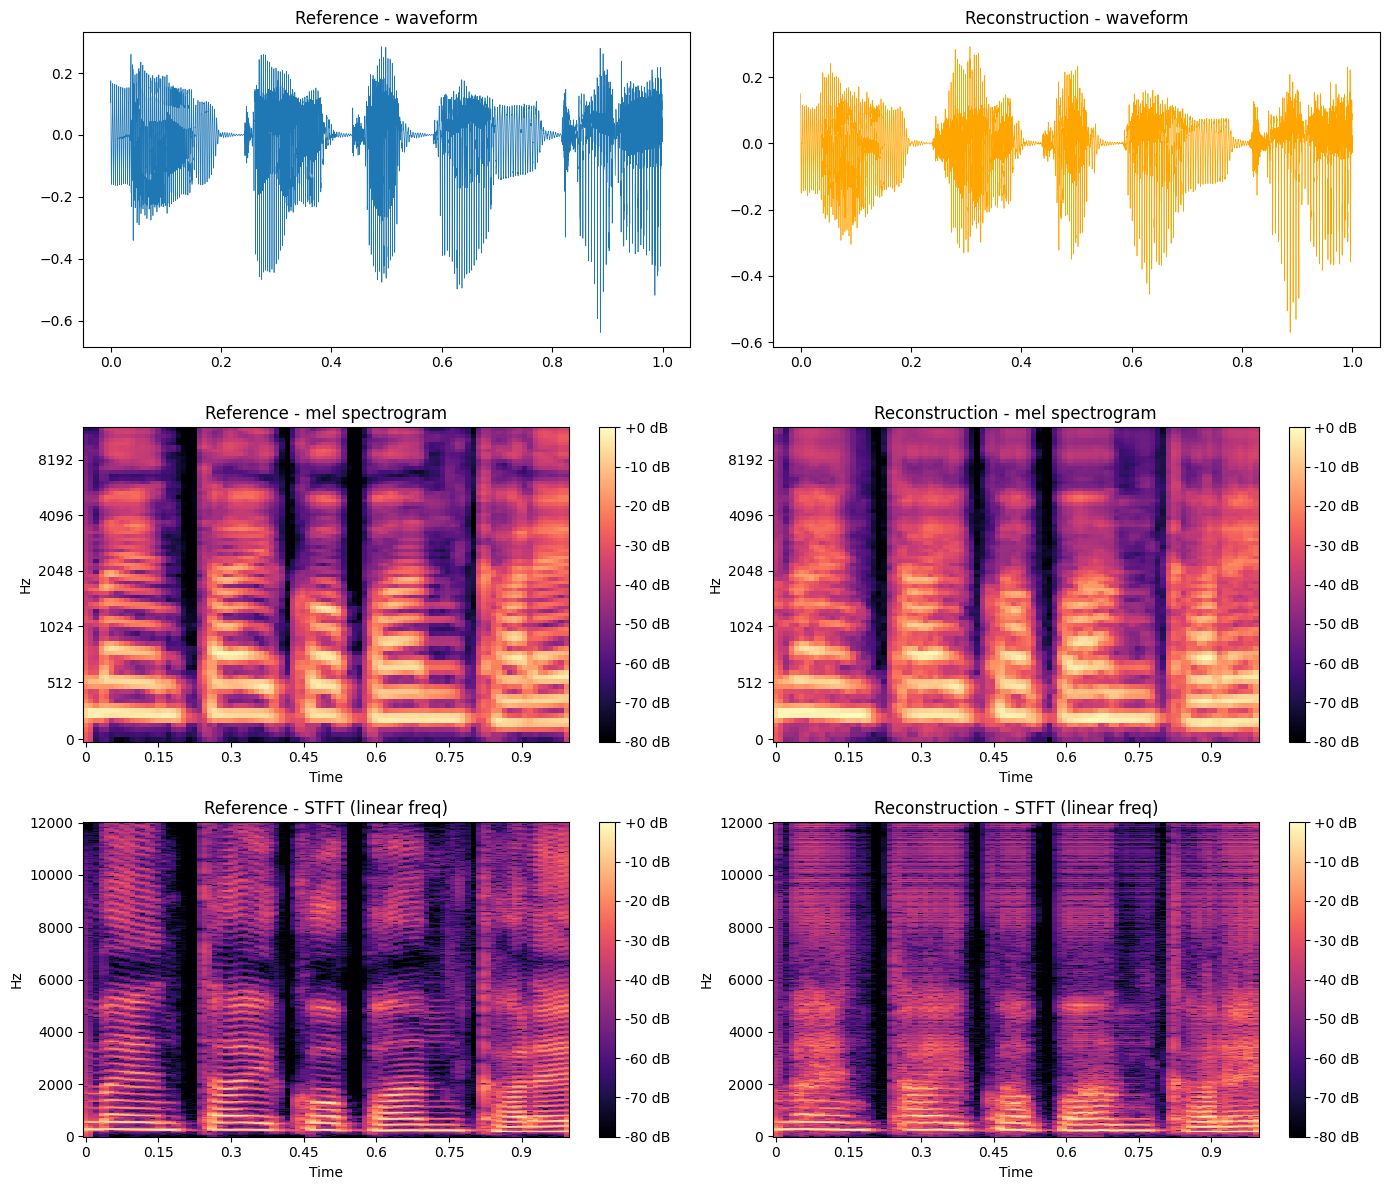

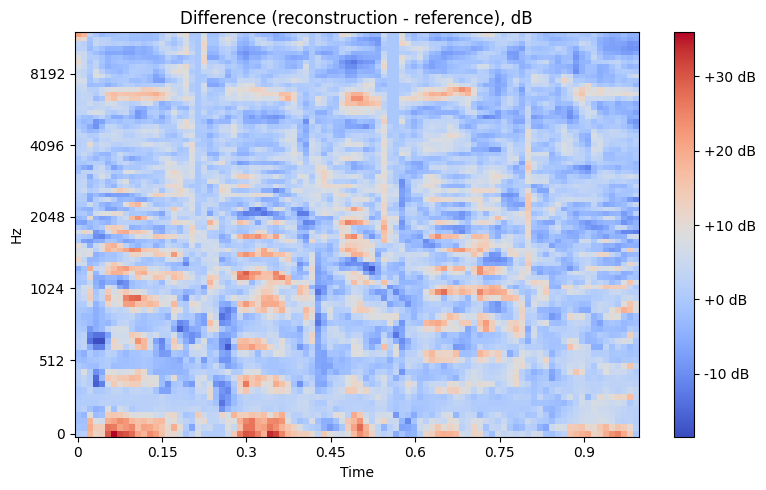

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# --- Chemins ---
audio_g = "/home/lois/wavenext/logs/12-06_at_09_16_17/wavenext/version_0/audio_epoch_280/sample_0_fake.wav"
audio_r = "/home/lois/wavenext/logs/12-06_at_09_16_17/wavenext/version_0/audio_epoch_280/sample_0_real.wav"

# --- Parametres STFT / mel ---
SR = 24000          # adapte si besoin (24kHz pour ton setup EnCodec)
N_FFT = 1024
HOP = 256
N_MELS = 80

def load(path):
    y, sr = librosa.load(path, sr=SR)
    return y, sr

def to_mel_db(y, sr):
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS
    )
    return librosa.power_to_db(mel, ref=np.max)

def to_stft_db(y, sr):
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP)
    return librosa.amplitude_to_db(np.abs(stft), ref=np.max)

y_g, sr_g = load(audio_g)
y_r, sr_r = load(audio_r)

# Aligner les longueurs si elles different legerement
min_len = min(len(y_g), len(y_r))
y_g, y_r = y_g[:min_len], y_r[:min_len]

mel_g, mel_r = to_mel_db(y_g, sr_g), to_mel_db(y_r, sr_r)
stft_g, stft_r = to_stft_db(y_g, sr_g), to_stft_db(y_r, sr_r)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# --- Waveform ---
t = np.linspace(0, len(y_r) / sr_r, len(y_r))
axes[0, 0].plot(t, y_r, linewidth=0.5)
axes[0, 0].set_title("Reference - waveform")
axes[0, 1].plot(t, y_g, linewidth=0.5, color="orange")
axes[0, 1].set_title("Reconstruction - waveform")

# --- Mel spectrogram ---
img1 = librosa.display.specshow(
    mel_r, sr=sr_r, hop_length=HOP, x_axis="time", y_axis="mel", ax=axes[1, 0]
)
axes[1, 0].set_title("Reference - mel spectrogram")
fig.colorbar(img1, ax=axes[1, 0], format="%+2.0f dB")

img2 = librosa.display.specshow(
    mel_g, sr=sr_g, hop_length=HOP, x_axis="time", y_axis="mel", ax=axes[1, 1]
)
axes[1, 1].set_title("Reconstruction - mel spectrogram")
fig.colorbar(img2, ax=axes[1, 1], format="%+2.0f dB")

# --- STFT (lineaire) -- utile pour reperer du bruit metallique / haute frequence ---
img3 = librosa.display.specshow(
    stft_r, sr=sr_r, hop_length=HOP, x_axis="time", y_axis="hz", ax=axes[2, 0]
)
axes[2, 0].set_title("Reference - STFT (linear freq)")
fig.colorbar(img3, ax=axes[2, 0], format="%+2.0f dB")

img4 = librosa.display.specshow(
    stft_g, sr=sr_g, hop_length=HOP, x_axis="time", y_axis="hz", ax=axes[2, 1]
)
axes[2, 1].set_title("Reconstruction - STFT (linear freq)")
fig.colorbar(img4, ax=axes[2, 1], format="%+2.0f dB")

plt.tight_layout()
out_path = "spectro_compare_epoch280.png"
plt.savefig(out_path, dpi=150)
print(f"Saved to {out_path}")

# --- Bonus : difference mel (reconstruction - reference) ---
fig2, ax = plt.subplots(figsize=(8, 5))
diff = mel_g - mel_r
img5 = librosa.display.specshow(
    diff, sr=sr_g, hop_length=HOP, x_axis="time", y_axis="mel", ax=ax, cmap="coolwarm"
)
ax.set_title("Difference (reconstruction - reference), dB")
fig2.colorbar(img5, ax=ax, format="%+2.0f dB")
plt.tight_layout()
plt.savefig("spectro_diff_epoch280.png", dpi=150)
print("Saved diff plot to spectro_diff_epoch280.png")

In [ ]:
import torch 
import yaml
from models.wavenext_prior import WaveNeXtLatent
from dataloader import WaveNeXtDataset
from torch.utils.data import random_split, DataLoader
import time


def load_config(config_path):
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    return config

config = load_config("/home/lois/wavenext/config_slowfast_24k.yaml")

dataset = WaveNeXtDataset(path_csv=config['dataset'], sample_rate=config['sample_rate'], samples=config['samples'])
train_size = int(0.8 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size


train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducible split
    )

gru = '/home/lois/wavenext/checkpoints/26-06_at_03_08_19/wavenext-epoch=45-val_mel_loss=1.122.ckpt'
tranformer = '/home/lois/wavenext/checkpoints/26-06_at_03_15_07/wavenext-epoch=49-val_mel_loss=1.130.ckpt'

model = WaveNeXtLatent.load_from_checkpoint(
    tranformer,
    dim=config['dim'],
    sample_rate=config['sample_rate'],
    fft_dim=config['fft_dim'],
    shift_dim=config['shift_dim'],
    n_mels=config['n_mels'],
    k=config['k'],
    lr_g=config['learning_rate_g'],
    lr_d=config['learning_rate_d'],
    prior=config['prior'],
    s_branch="tranformer"
).to('cuda')
model.eval()

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)
x = next(iter(test_loader)).to('cuda')

with torch.no_grad():
    split = int(x.size(2)*(2/3))
    x_fast = x[:, :, split:]
    x_slow = x[:, :, :split]

    t0 = time.perf_counter()

    encoded_frames = model.encoder.encode(x_fast)
    codes = torch.cat([f[0] for f in encoded_frames], dim=-1)
    fast_chunk = model.encoder.quantizer.decode(codes.transpose(0, 1))

    slow_chunk = model.mel_extractor(x_slow).squeeze(1)
    slow_chunk = slow_chunk.transpose(1,2)

    cond = model.slow_branch(slow_chunk)
    fake = model.decoder(fast_chunk, cond)

t1 = time.perf_counter()

print((t1 - t0)*1000)

/home/lois/miniconda3/envs/latency/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/lois/miniconda3/envs/latency/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File 

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

The above exception was the direct cause of the following exception:

SystemError: <built-in function __import__> returned a result with an exception set

/home/lois/miniconda3/envs/latency/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



KeyboardInterrupt



In [5]:
import torch
import dac
#from audiotools import AudioSignal

model_path = dac.utils.download(model_type="44khz")
model = dac.DAC.load(model_path)

# Load audio signal file
signal = torch.randn(1,1,44100)

# Encode audio signal as one long file
# (may run out of GPU memory on long files)
signal.to(model.device)

x = model.preprocess(signal, 44100)
z, codes, latents, _, _ = model.encode(x)
print(z.shape, codes.shape, latents.shape)


/home/lois/miniconda3/envs/dac/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


torch.Size([1, 1024, 87]) torch.Size([1, 9, 87]) torch.Size([1, 72, 87])


In [12]:
from encodec import EncodecModel
from encodec.utils import convert_audio
import torchaudio

wav = torchaudio.load('/home/lois/wavenext/logs/26-06_at_03_08_19/wavenext/version_0/audio_epoch_160/sample_0_real.wav')[0]

model = EncodecModel.encodec_model_24khz()
model.set_target_bandwidth(6.0)

print(wav.shape)

with torch.no_grad():
    encoded_frames = model.encode(wav.unsqueeze(1))  # liste de (codes, scale)
    codes = torch.cat([f[0] for f in encoded_frames], dim=-1)  # [B, n_q, T]
    emb = model.quantizer.decode(codes.transpose(0, 1))
    print(f"emb shape : {emb.shape}")  # [1, 128, 75]


torch.Size([1, 24000])
emb shape : torch.Size([1, 128, 75])


In [ ]:
import torch
import soundfile as sf
import numpy as np
import librosa
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from encodec import EncodecModel

REAL_WAV = '/home/lois/wavenext/logs/26-06_at_03_08_19/wavenext/version_0/audio_epoch_160/sample_0_real.wav'

# --- Charger le wav réel ---
y, sr = sf.read(REAL_WAV)
wav = torch.from_numpy(y).float().unsqueeze(0).unsqueeze(0)  # [1, 1, T]

# --- Encodec seul, 24kHz, 6kbps (ta config actuelle) ---
model = EncodecModel.encodec_model_24khz()
model.set_target_bandwidth(6.0)

with torch.no_grad():
    encoded_frames = model.encode(wav)
    decoded = model.decode(encoded_frames)

roundtrip = decoded.squeeze().numpy()
sf.write('real_encodec_roundtrip_6kbps.wav', roundtrip, model.sample_rate)

# --- Comparaison spectrale ---
n_fft, hop = 1024, 256
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, sig, name in [(axes[0], y, 'real'), (axes[1], roundtrip, 'encodec_roundtrip_6kbps')]:
    S = librosa.stft(sig.astype(np.float32), n_fft=n_fft, hop_length=hop)
    Sdb = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    img = librosa.display.specshow(Sdb, sr=sr, hop_length=hop, x_axis='time', y_axis='hz',
                                    ax=ax, cmap='magma', vmin=-80, vmax=0)
    ax.set_title(name)
    ax.set_ylim(0, 8000)
plt.tight_layout()
plt.savefig('encodec_bottleneck_test.png', dpi=130)

sf_real = librosa.feature.spectral_flatness(y=y.astype(np.float32), n_fft=n_fft, hop_length=hop).mean()
sf_rt = librosa.feature.spectral_flatness(y=roundtrip.astype(np.float32), n_fft=n_fft, hop_length=hop).mean()
print(f"Spectral flatness - real: {sf_real:.4f} | encodec_roundtrip_6kbps: {sf_rt:.4f}")
print("(pour rappel, sur tes sorties : real=0.0050, gru=0.0103, transformer=0.0125)")

# Bonus: refaire le test à pleine bande passante (24kbps) pour voir le delta
model.set_target_bandwidth(24.0)
with torch.no_grad():
    encoded_frames_hi = model.encode(wav)
    decoded_hi = model.decode(encoded_frames_hi)
roundtrip_hi = decoded_hi.squeeze().numpy()
sf_rt_hi = librosa.feature.spectral_flatness(y=roundtrip_hi.astype(np.float32), n_fft=n_fft, hop_length=hop).mean()
print(f"Spectral flatness - encodec_roundtrip_24kbps (max bitrate): {sf_rt_hi:.4f}")

/home/lois/miniconda3/envs/latency/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Spectral flatness - real: 0.0050 | encodec_roundtrip_6kbps: 0.0048
(pour rappel, sur tes sorties : real=0.0050, gru=0.0103, transformer=0.0125)
Spectral flatness - encodec_roundtrip_24kbps (max bitrate): 0.0056
